In [171]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "/content/Dataset/Dataset"
SAMPLE_RATE = 16000
BATCH_SIZE = 32

class_names = sorted(os.listdir(DATA_DIR))
num_classes = len(class_names)

label_to_index = {name: i for i, name in enumerate(class_names)}

print("Luokat:", class_names)

Luokat: ['Alas', 'Aloita', 'Avaa', 'Ei', 'Jatka', 'Kyllä', 'Käynnistä', 'Lopeta', 'Oikea', 'Pysäytä', 'Sulje', 'Tauko', 'Vasen', 'Ylös']


In [172]:
file_paths = []
labels = []

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    for fname in os.listdir(class_dir):
        if fname.endswith(".wav"):
            file_paths.append(os.path.join(class_dir, fname))
            labels.append(label_to_index[class_name])

file_paths = tf.constant(file_paths)
labels = tf.constant(labels)

In [173]:
def load_wav(path, label):
    audio, _ = tf.audio.decode_wav(
        tf.io.read_file(path),
        desired_channels=1
    )
    audio = tf.squeeze(audio, axis=-1)
    audio = audio[:SAMPLE_RATE]
    audio = tf.pad(audio, [[0, SAMPLE_RATE - tf.shape(audio)[0]]])
    return audio, label

In [174]:
def audio_to_mel(audio):
    stft = tf.signal.stft(audio, 1024, 256)
    spec = tf.abs(stft)

    mel_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=40,
        num_spectrogram_bins=spec.shape[-1],
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz=80,
        upper_edge_hertz=7600
    )

    mel = tf.tensordot(spec, mel_matrix, 1)
    mel = tf.math.log(mel + 1e-6)
    mel = (mel - tf.reduce_mean(mel)) / (tf.math.reduce_std(mel) + 1e-6)
    mel = tf.expand_dims(mel, -1)

    return mel

In [175]:
# NOTE:
# Seuraava SpecAugment‑funktio on toteutettu projektia varten,
# mutta EI ole käytössä lopullisessa mallissa, koska kokeilujen
# perusteella se heikensi suorituskykyä pienen datasetin vuoksi.

# def spec_augment(mel, label, freq_mask=5, time_mask=10):
#     mel = tf.squeeze(mel, axis=-1)
#
#     time_dim = tf.shape(mel)[0]
#     freq_dim = tf.shape(mel)[1]
#
#     f = tf.random.uniform([], 0, tf.maximum(1, freq_dim - freq_mask), dtype=tf.int32)
#     mel = tf.concat(
#         [mel[:, :f],
#          tf.zeros([time_dim, freq_mask]),
#          mel[:, f + freq_mask:]],
#         axis=1
#     )
#
#     t = tf.random.uniform([], 0, tf.maximum(1, time_dim - time_mask), dtype=tf.int32)
#     mel = tf.concat(
#         [mel[:t, :],
#          tf.zeros([time_mask, freq_dim]),
#          mel[t + time_mask:, :]],
#         axis=0
#     )
#
#     mel = tf.expand_dims(mel, -1)
#     return mel, label

In [176]:
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
dataset = dataset.map(load_wav, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.map(lambda x, y: (audio_to_mel(x), y),
                      num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(1000)

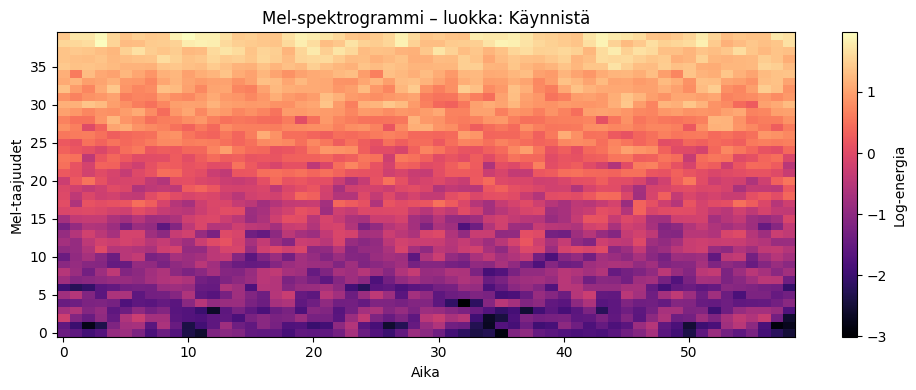

In [177]:
for mel, label in dataset.take(1):
    mel_img = tf.squeeze(mel).numpy()   # (time, mel_bins)
    label_idx = int(label.numpy())
    label_name = class_names[label_idx]

    plt.figure(figsize=(10, 4))
    plt.imshow(
        mel_img.T,
        aspect="auto",
        origin="lower",
        cmap="magma"
    )
    plt.title(f"Mel-spektrogrammi – luokka: {label_name}")
    plt.xlabel("Aika")
    plt.ylabel("Mel-taajuudet")
    plt.colorbar(label="Log‑energia")
    plt.tight_layout()
    plt.show()

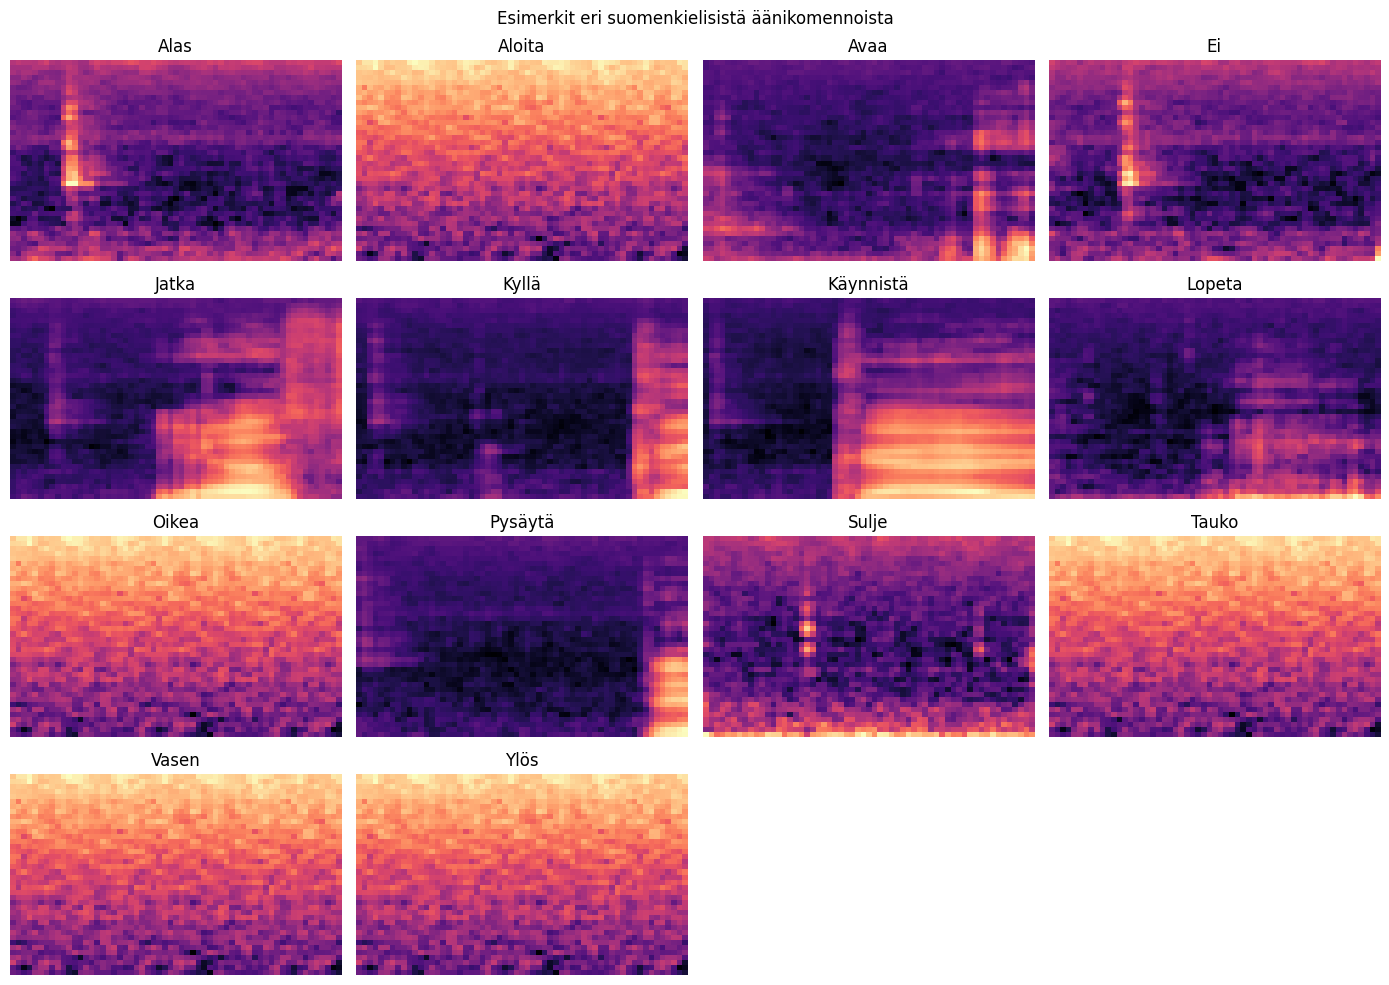

In [178]:
examples = {}
labels_seen = set()

for mel, label in dataset:
    label_idx = int(label.numpy())
    if label_idx not in examples:
        examples[label_idx] = mel

    if len(examples) == len(class_names):
        break


plt.figure(figsize=(14, 10))

for i, (label_idx, mel) in enumerate(sorted(examples.items())):
    plt.subplot(4, 4, i + 1)
    mel_img = tf.squeeze(mel).numpy()

    plt.imshow(
        mel_img.T,
        aspect="auto",
        origin="lower",
        cmap="magma"
    )
    plt.title(class_names[label_idx])
    plt.axis("off")

plt.suptitle("Esimerkit eri suomenkielisistä äänikomennoista")
plt.tight_layout()
plt.show()

In [179]:
raw_audio_ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
raw_audio_ds = raw_audio_ds.map(load_wav)

In [180]:
audio, label = next(iter(raw_audio_ds))
label_name = class_names[label]

In [181]:
def add_noise(audio, factor=0.02):
    noise = tf.random.normal(tf.shape(audio))
    return audio + factor * noise

clean_mel = audio_to_mel(audio)
noisy_mel = audio_to_mel(add_noise(audio))

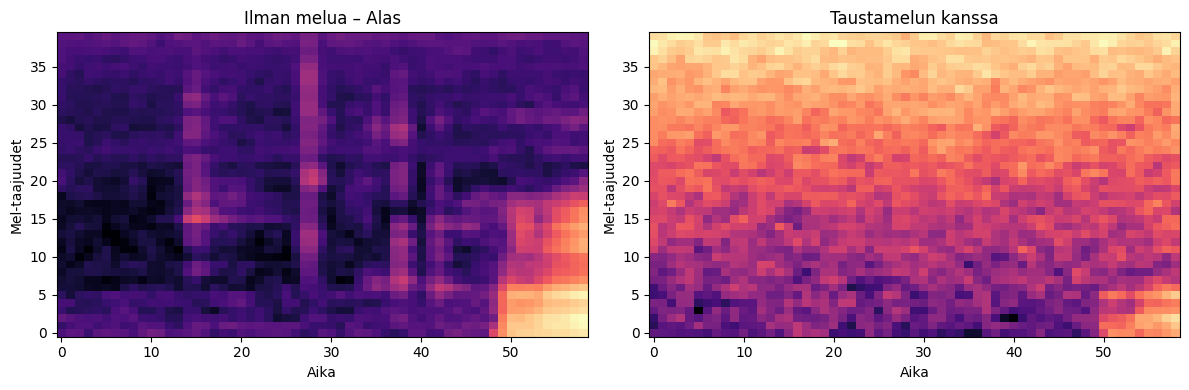

In [182]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title(f"Ilman melua – {label_name}")
plt.imshow(
    tf.squeeze(clean_mel).numpy().T,
    aspect="auto",
    origin="lower",
    cmap="magma"
)
plt.xlabel("Aika")
plt.ylabel("Mel-taajuudet")

plt.subplot(1, 2, 2)
plt.title("Taustamelun kanssa")
plt.imshow(
    tf.squeeze(noisy_mel).numpy().T,
    aspect="auto",
    origin="lower",
    cmap="magma"
)
plt.xlabel("Aika")
plt.ylabel("Mel-taajuudet")

plt.tight_layout()
plt.show()

In [183]:
dataset_size = tf.data.experimental.cardinality(dataset).numpy()
train_size = int(0.8 * dataset_size)

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [184]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None, 40, 1)),

    tf.keras.layers.Conv2D(32, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])


In [185]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [186]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40
)

Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.0774 - loss: 2.7237 - val_accuracy: 0.0893 - val_loss: 2.6359
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.0982 - loss: 2.6534 - val_accuracy: 0.0893 - val_loss: 2.6382
Epoch 3/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.1161 - loss: 2.6180 - val_accuracy: 0.1488 - val_loss: 2.6260
Epoch 4/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.1146 - loss: 2.5951 - val_accuracy: 0.0952 - val_loss: 2.6327
Epoch 5/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.1429 - loss: 2.5669 - val_accuracy: 0.0893 - val_loss: 2.6395
Epoch 6/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.1399 - loss: 2.5517 - val_accuracy: 0.0595 - val_loss: 2.6390
Epoch 7/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.1131 - loss: 2.5612 - val_accuracy: 0.0893 - val_loss: 2.6396
Epoch 8/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.1667 - loss: 2.5333 - val_accuracy: 0.0774

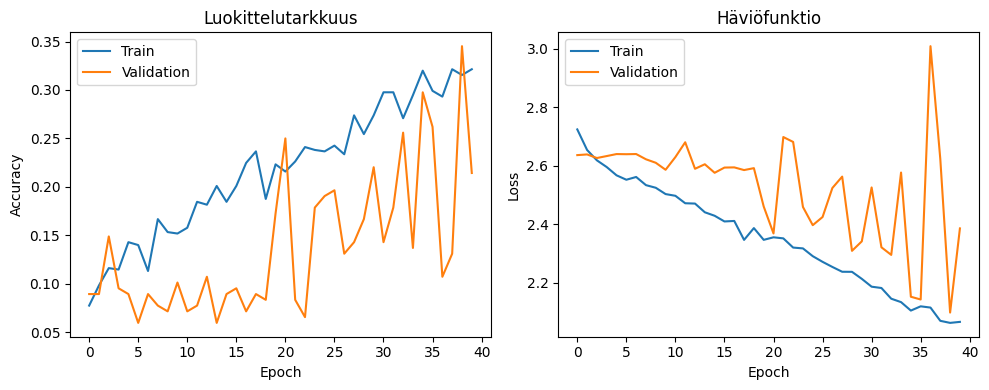

In [187]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Luokittelutarkkuus")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Häviöfunktio")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [188]:
import numpy as np

y_true = []
y_pred = []

for mel, label in val_ds:
    predictions = model.predict(mel, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(label.numpy())
    y_pred.extend(predicted_labels)


In [190]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm.shape)


(14, 14)


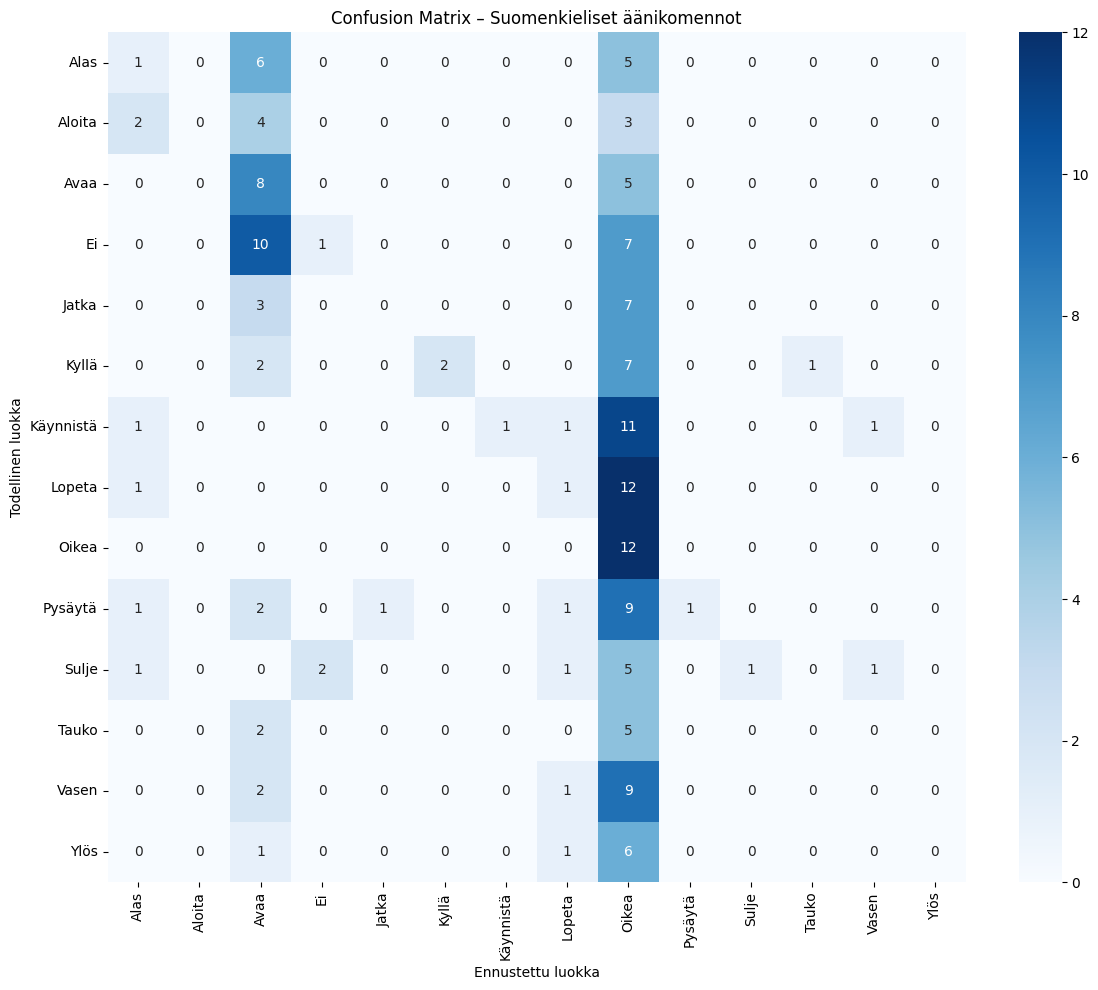

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Ennustettu luokka")
plt.ylabel("Todellinen luokka")
plt.title("Confusion Matrix – Suomenkieliset äänikomennot")
plt.tight_layout()
plt.show()

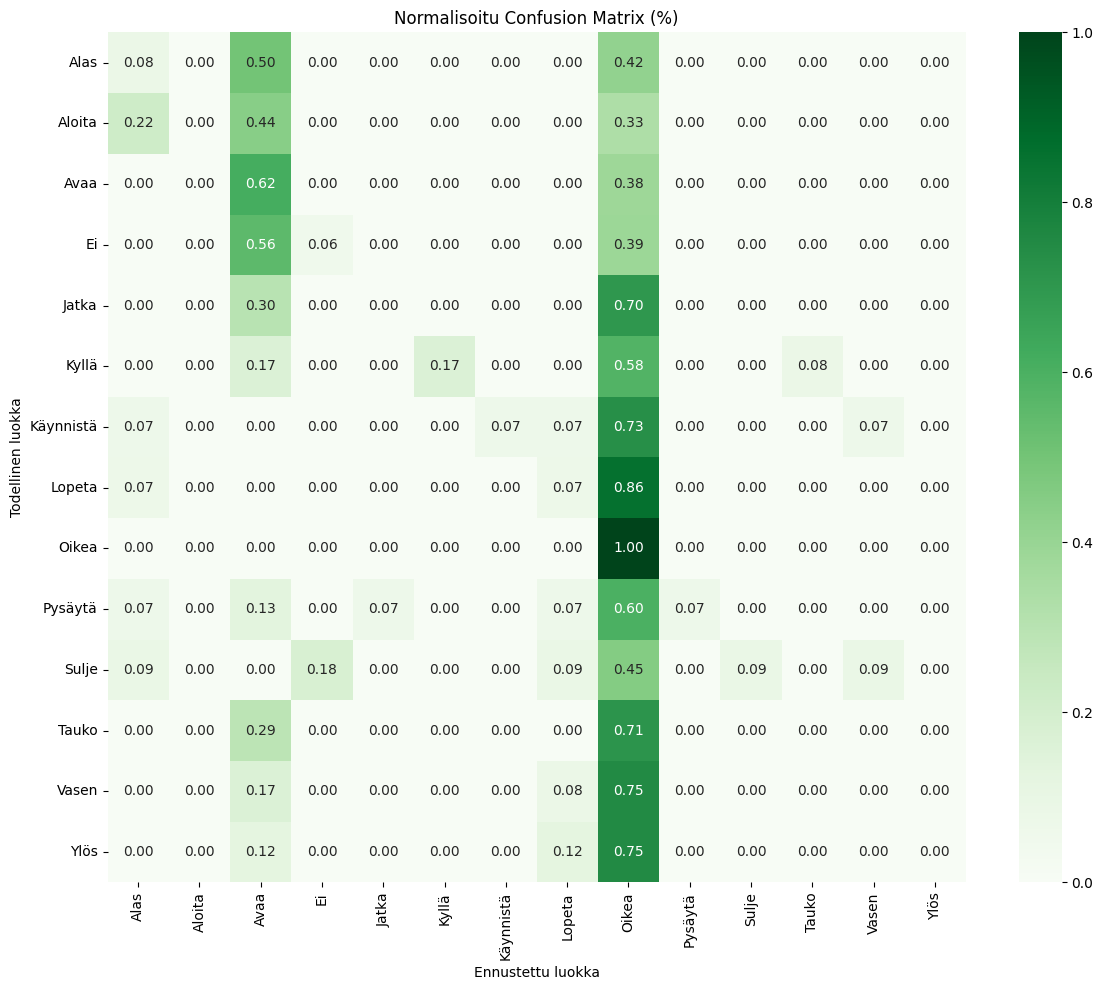

In [193]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt=".2f",
    cmap="Greens"
)

plt.xlabel("Ennustettu luokka")
plt.ylabel("Todellinen luokka")
plt.title("Normalisoitu Confusion Matrix (%)")
plt.tight_layout()
plt.show()

Confusion Matrix ‑analyysi  
  
Confusion matrix osoittaa, että malli ennustaa suuren osan komennoista samaksi luokaksi (“Oikea”). Tämä ilmiö johtuu datan pienestä koosta, suuresta luokkamäärästä sekä joidenkin komentojen akustisesta samankaltaisuudesta. Malli on ajautunut paikalliseen minimiin, jossa yhden luokan suosiminen minimoi häviöfunktion. Tämä on tyypillinen ilmiö pienissä moniluokkaluokitteluongelmissa.